# 1.환경 준비

In [1]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

In [2]:
# 데이터 불러오기
path = 'data/mobile_cust_churn.csv'
df = pd.read_csv(path)
df['CHURN'] = df['CHURN'].map({'STAY':0, 'LEAVE': 1})

# 2.데이터 이해

In [3]:
# 데이터 살펴보기
df.head()

,id,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION,REPORTED_USAGE_LEVEL,CONSIDERING_CHANGE_OF_PLAN,CHURN
0,1,0,31953,0,6,313378,161,0,4,unsat,little,no,0
1,2,1,36147,0,13,800586,244,0,6,unsat,little,considering,0
2,3,1,27273,230,0,305049,201,16,15,unsat,very_little,perhaps,0
3,4,0,120070,38,33,788235,780,3,2,unsat,very_high,considering,1
4,5,1,29215,208,85,224784,241,21,1,very_unsat,little,never_thought,0


**데이터 설명**

- COLLEGE: 대학 졸업여부
- INCOME: 연수입
- OVERAGE: 월평균 초과사용 시간(분)
- LEFTOVER: 월평균 잔여시간비율(%)
- HOUSE: 집값
- HANDSET_PRICE: 스마트폰 가격
- OVER_15MINS_CALLS_PER_MONTH: 월평균 장기통화(15분이상) 횟수
- AVERAGE_CALL_DURATION: 평균 통화 시간
- REPORTED_SATISFACTION: 만족도 설문조사 결과
- REPORTED_USAGE_LEVEL: 사용도 자가진단 결과
- CONSIDERING_CHANGE_OF_PLAN: 향후 변경계획 설문조사 결과
- CHURN: 이탈(번호이동) 여부

In [4]:
# 기술통계 확인
df.describe()

,id,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,CHURN
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,0.502400,80281.447750,85.979550,23.898650,493155.264250,389.615100,8.000700,6.002250,0.492600
std,5773.647028,0.500007,41680.586319,85.992324,26.816645,252407.884692,213.820682,8.925418,4.402558,0.499958
min,1.000000,0.000000,20007.000000,-2.000000,0.000000,150002.000000,130.000000,0.000000,1.000000,0.000000
25%,5000.750000,0.000000,42217.000000,0.000000,0.000000,263714.250000,219.000000,1.000000,2.000000,0.000000
50%,10000.500000,1.000000,75366.500000,59.000000,14.000000,452259.500000,326.000000,4.000000,5.000000,0.000000
75%,15000.250000,1.000000,115881.750000,179.000000,41.000000,702378.000000,533.250000,15.000000,10.000000,1.000000
max,20000.000000,1.000000,159983.000000,335.000000,89.000000,999996.000000,899.000000,29.000000,15.000000,1.000000


# 3.데이터 전처리

**1) 변수 제거**

In [5]:
# 제거 대상: id
drop_cols = ['id']

# 변수 제거
df.drop(drop_cols, axis=1, inplace=True)

# 확인
df.head()

,COLLEGE,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION,REPORTED_SATISFACTION,REPORTED_USAGE_LEVEL,CONSIDERING_CHANGE_OF_PLAN,CHURN
0,0,31953,0,6,313378,161,0,4,unsat,little,no,0
1,1,36147,0,13,800586,244,0,6,unsat,little,considering,0
2,1,27273,230,0,305049,201,16,15,unsat,very_little,perhaps,0
3,0,120070,38,33,788235,780,3,2,unsat,very_high,considering,1
4,1,29215,208,85,224784,241,21,1,very_unsat,little,never_thought,0


In [6]:
# 제거 대상: id
drop_cols_2 = ['COLLEGE', 'REPORTED_SATISFACTION', 'REPORTED_USAGE_LEVEL', 'CONSIDERING_CHANGE_OF_PLAN', 'OVER_15MINS_CALLS_PER_MONTH', 'AVERAGE_CALL_DURATION']

# 변수 제거
df.drop(drop_cols_2, axis=1, inplace=True)

# 확인
df.head()

,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,CHURN
0,31953,0,6,313378,161,0
1,36147,0,13,800586,244,0
2,27273,230,0,305049,201,0
3,120070,38,33,788235,780,1
4,29215,208,85,224784,241,0


**2) x, y 분리**

In [7]:
# Target 설정
target = 'CHURN'

# 데이터 분리
X = df.drop(target, axis=1)
y = df[target]


**3) 가변수화**

**4) 학습용, 평가용 데이터 분리**

In [8]:
# 모듈 불러오기
from sklearn.model_selection import train_test_split

# 7:3으로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.7,
                                                    random_state=1
                                                    )

**5) 정규화**

In [9]:
# 모듈 불러오기
from sklearn.preprocessing import MinMaxScaler

# 정규화
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)




# 4.성능 예측

- 여러 알고리즘으로 모델을 만들고 K-Fold CV로 성능을 예측한다.
- 하이퍼파라미터를 설정하지 않고 진행한다.
- 각 모델의 성능 정보를 수집해 마지막에 비교한다.

In [10]:
# xgboost 설치
# pip install xgboost

In [11]:
# lightgbm 설치
# pip install lightgbm

- 이후 사용할 함수 모두 불러오기

In [12]:
# 라이브러리 불러오기
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import *
from sklearn.model_selection import cross_val_score


**1) KNN**

- KNN 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [13]:
# 선언하기
model_knn = KNeighborsClassifier()

In [14]:
# 성능예측
cv_score = cross_val_score(model_knn, X_train, y_train, cv=5, scoring ='accuracy')

In [15]:
# 결과확인
print(cv_score)
print('평균 :', cv_score.mean())
print('표준편차 :', cv_score.std())

[0.66964286 0.66285714 0.65535714 0.65964286 0.66071429]
평균 : 0.6616428571428571
표준편차 : 0.004687151347577953


In [16]:
# 결과수집
result = {}
result['KNN'] = cv_score.mean()

**2) Decision Tree**

- Decision Tree 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [17]:
# 선언하기
model_dt = DecisionTreeClassifier(max_depth=5, random_state=1)

In [18]:
# 성능예측
cv_score = cross_val_score(model_dt, X_train, y_train, cv=5, scoring='accuracy')

In [19]:
# 결과확인
print(cv_score)
print('평균 :', cv_score.mean())
print('표준편차 :', cv_score.std())

[0.69714286 0.69928571 0.69178571 0.69821429 0.69857143]
평균 : 0.6970000000000001
표준편차 : 0.002697315369785584


In [20]:
# 결과수집
result['DT'] = cv_score.mean()

**3) Logistic Regression**

- Logistic Regression 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [21]:
# 선언하기
model_lr = LogisticRegression()

In [22]:
# 성능예측
cv_score = cross_val_score(model_lr, X_train, y_train, cv=5, scoring='accuracy')

In [23]:
# 결과확인
print(cv_score)
print('평균 :', cv_score.mean())
print('표준편차 :', cv_score.std())

[0.63178571 0.6425     0.63392857 0.65035714 0.63892857]
평균 : 0.6395000000000001
표준편차 : 0.006599319692829201


In [24]:
# 결과수집
result['LR'] = cv_score.mean()

**4) SVM**

- SVM 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [25]:
# 선언하기
model_svc = SVC(kernel='linear', C=1, random_state=1)

In [26]:
# 성능예측
cv_score = cross_val_score(model_svc, X_train, y_train, cv=5, scoring='accuracy')

In [27]:
# 결과확인
print(cv_score)
print('평균 :', cv_score.mean())
print('표준편차 :', cv_score.std())

[0.62142857 0.63857143 0.62821429 0.64892857 0.64678571]
평균 : 0.6367857142857142
표준편차 : 0.010582523135735033


In [28]:
# 결과수집
result['SVC'] = cv_score.mean()

**5) Random Forest**

- Random Forest 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [29]:
# 선언하기
model_rf = RandomForestClassifier()

In [30]:
# 성능예측
cv_score = cross_val_score(model_rf, X_train, y_train, cv=5, scoring='accuracy')

In [31]:
# 결과확인
print(cv_score)
print(cv_score.mean())
print(cv_score.std())

[0.68571429 0.70178571 0.69428571 0.69464286 0.69535714]
0.6943571428571429
0.005117995462192228


In [32]:
# 결과수집
result['RF'] = cv_score.mean()

**6) XGBoost**

- XGBoost 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [33]:
# 선언하기
model_xgb = XGBClassifier()

In [34]:
# 성능예측
cv_score = cross_val_score(model_xgb, X_train, y_train, cv=5, scoring='accuracy')

In [35]:
# 결과확인
print(cv_score)
print(cv_score.mean())
print(cv_score.std())

[0.67785714 0.7        0.67928571 0.69214286 0.695     ]
0.6888571428571428
0.008778452283278403


In [36]:
# 결과수집
result['XGB'] = cv_score.mean()

**7) LightGBM**

- LightGBM 알고리즘으로 모델링하고 K-Fold CV로 성능 검증

In [37]:
# 선언하기
model_lgbm = LGBMClassifier(min_child_samples=5,
                            max_depth=15,
                            min_split_gain=0.0,
                            colsample_bytree=1.0,
                            verbose=-1
                            )

In [38]:
# 성능예측
cv_score = cross_val_score(model_lgbm, X_train, y_train, cv=5, scoring='accuracy')

In [39]:
# 결과확인
print(cv_score)
print(cv_score.mean())
print(cv_score.std())

[0.69464286 0.71035714 0.69678571 0.695      0.70214286]
0.6997857142857142
0.00592728041020711


In [40]:
# 결과수집
result['LGBM'] = cv_score.mean()

# 5.결과 확인

- 예측된 각 모델의 성능 비교

In [41]:
# 성능 비교
df_result = pd.DataFrame.from_dict(result, orient='index', columns=['score'])
df_result.sort_values(by='score', ascending=True, inplace=True)

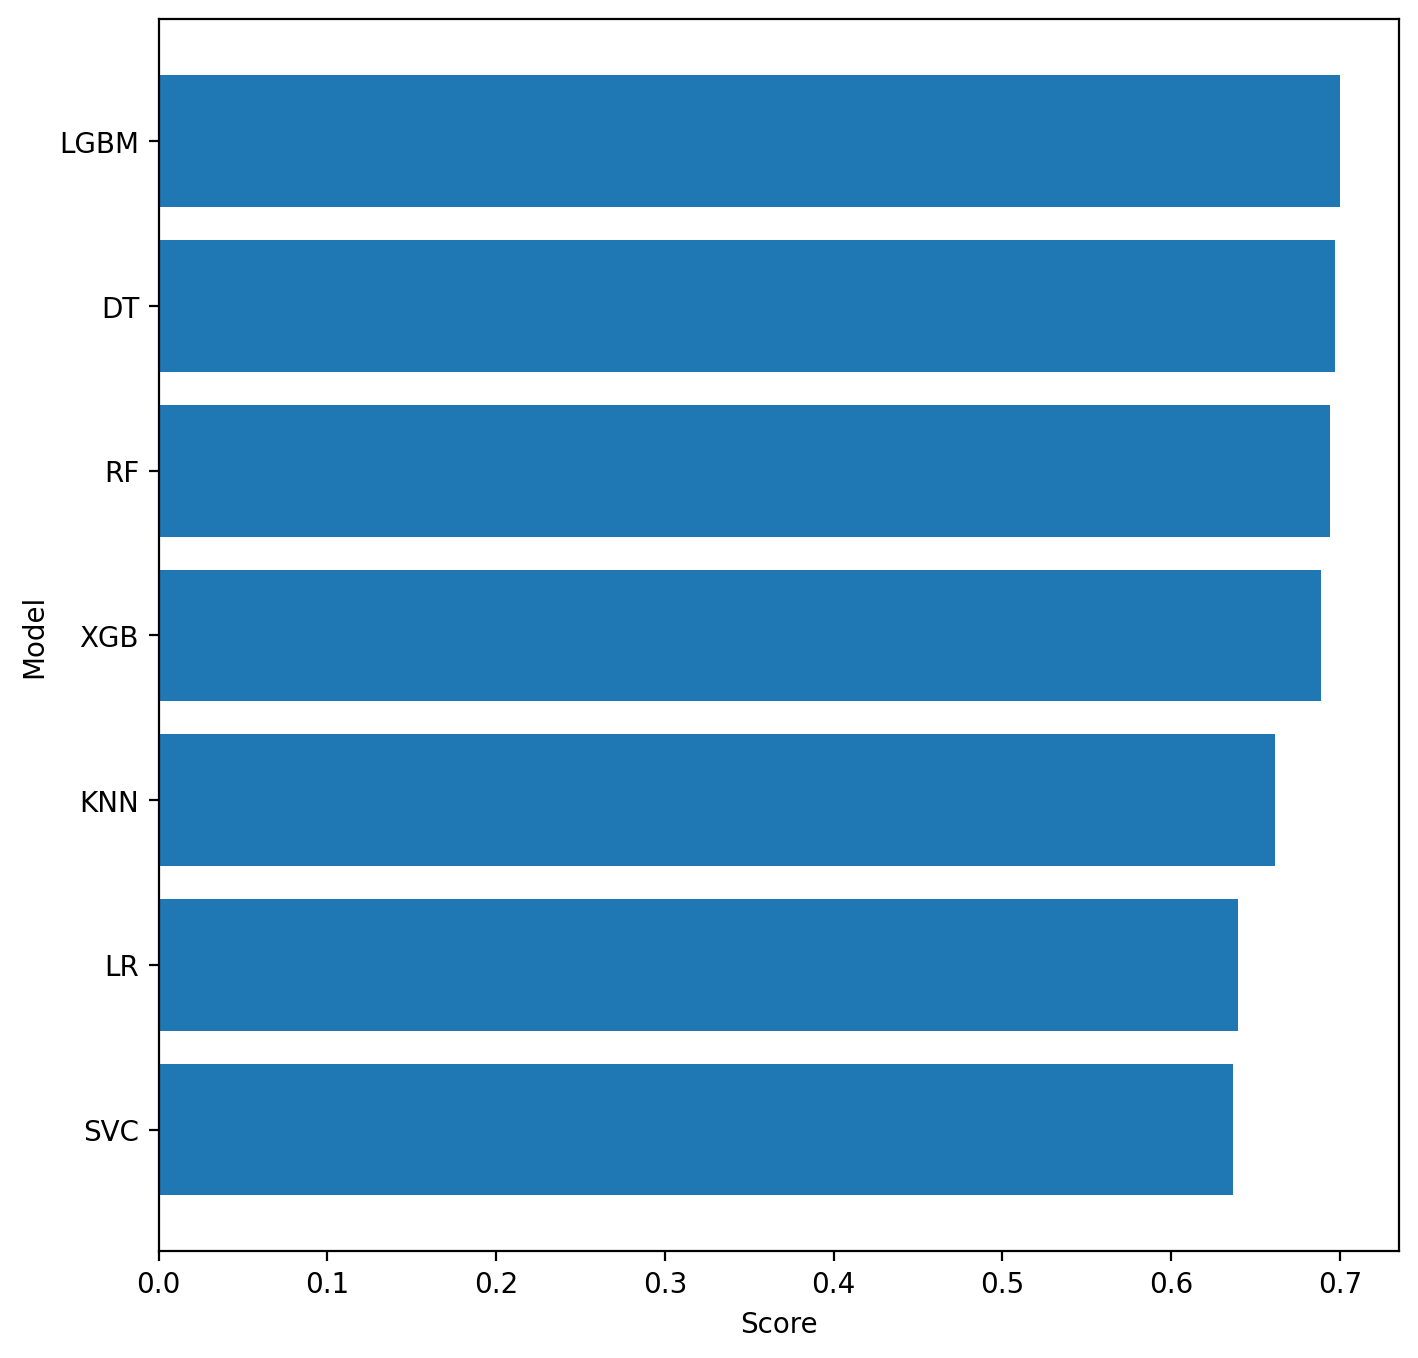

In [42]:
# 성능 시각화 비교
plt.figure(figsize=(8,8))
plt.barh(y=df_result.index, width=df_result['score'])
plt.xlabel('Score')
plt.ylabel('Model')
plt.show()

# 6.성능 튜닝

- 위에서 성능이 가장 좋을 것으로 예측된 모델 튜닝

In [43]:
from sklearn.model_selection import GridSearchCV
# 기본 모델 선언
modelno1 = model_dt

# 파라미터 지정
param = {'max_depth': range(1,51)}


# 모델 선언
model = GridSearchCV(modelno1,
                      param,
                      cv=5,
                      scoring='accuracy')




In [44]:
# 학습하기(많은 시간이 소요될 수 있음)
model.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(1, 51)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate

In [45]:
# mean_test_score 확인
print(model.cv_results_['mean_test_score'])
print('='*70)
print('최적의 파라미터: ', model.best_params_)
print('='*70)
print('최고의 성능: ', model.best_score_)

[0.61735714 0.65607143 0.68907143 0.69957143 0.697      0.69785714
 0.69628571 0.69135714 0.6905     0.684      0.67728571 0.67578571
 0.66742857 0.6635     0.65935714 0.65421429 0.64921429 0.64442857
 0.6385     0.63735714 0.63171429 0.62942857 0.63028571 0.62914286
 0.62521429 0.62207143 0.62192857 0.622      0.62042857 0.61921429
 0.61907143 0.61914286 0.61785714 0.61857143 0.61807143 0.61778571
 0.62014286 0.61871429 0.61978571 0.61978571 0.61978571 0.61978571
 0.61978571 0.61978571 0.61978571 0.61978571 0.61978571 0.61978571
 0.61978571 0.61978571]
최적의 파라미터:  {'max_depth': 4}
최고의 성능:  0.6995714285714286


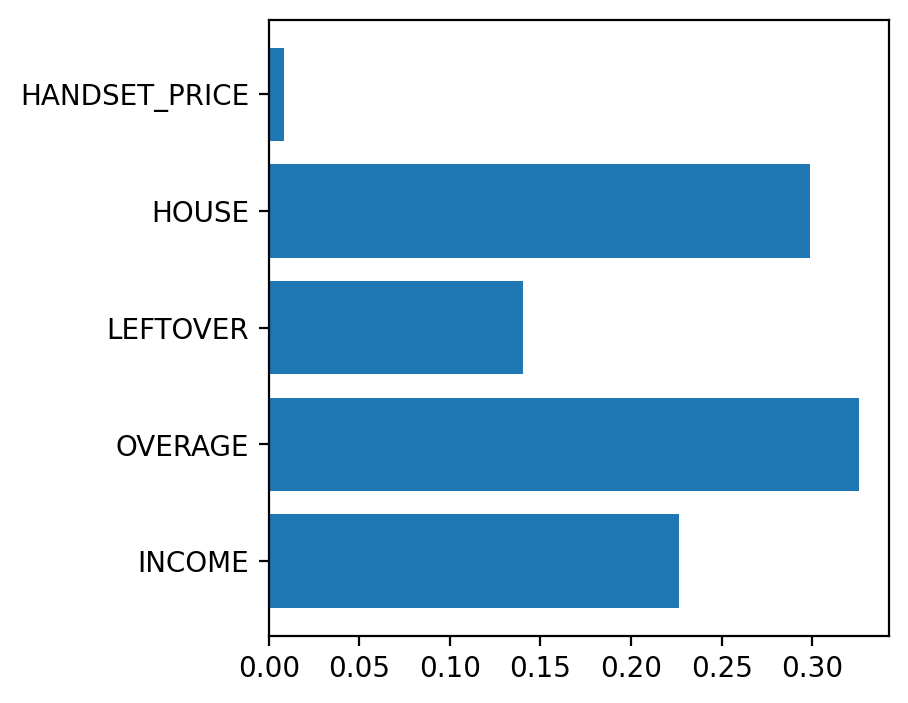

In [49]:
# 변수 중요도 시각화
plt.figure(figsize=(4,4))
plt.barh(y=list(X), width=model.best_estimator_.feature_importances_)
plt.show()



# 7.성능 평가

- 최적 파라미터로 학습된 모델에 대해 최종 성능 평가 진행

In [47]:
# 예측하기
y_pred = model.predict(X_test)

In [48]:
# 평가하기
print('CM :', confusion_matrix(y_test, y_pred))
print('='*70)
print('Class_report :', classification_report(y_test, y_pred))

CM : [[1930 1135]
 [ 646 2289]]
Class_report :               precision    recall  f1-score   support

           0       0.75      0.63      0.68      3065
           1       0.67      0.78      0.72      2935

    accuracy                           0.70      6000
   macro avg       0.71      0.70      0.70      6000
weighted avg       0.71      0.70      0.70      6000

